In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/output_dataset.zip

Archive:  /content/drive/MyDrive/output_dataset.zip
   creating: crop_mask/
   creating: damage_mask/
   creating: original/
   creating: overlay/
  inflating: damage_mask/IMG_3027_jpeg.rf.4f6a90495d72480e77b387a78ee2d64f.jpg  
  inflating: damage_mask/IMG_2639_jpeg.rf.8e1221120b4a24303f573e9af0ba0617.jpg  
  inflating: damage_mask/IMG_2970_jpeg.rf.bf8a0815d8bcef2505e5957cb320a920.jpg  
  inflating: damage_mask/IMG_2705_jpeg.rf.87d4b2dc65e7544db6581f153d712164.jpg  
  inflating: damage_mask/IMG_2923_jpeg.rf.110354f641b1d637d359206a67585430.jpg  
  inflating: damage_mask/IMG_2524_jpeg.rf.170f8f875148a773df53f04a5ecc951a.jpg  
  inflating: damage_mask/IMG_2625_jpeg.rf.605ed60c8c5158fc70a20def06813684.jpg  
  inflating: damage_mask/IMG_2568_jpeg.rf.d5e2dffbdfa232300dffeaf54f5f12cf.jpg  
  inflating: damage_mask/IMG_2734_jpeg.rf.31d8bfed188b344a5e9e6064b096fd45.jpg  
  inflating: damage_mask/IMG_2723_jpeg.rf.c3870a17da0cbe2d8104f5c2d5ee901c.jpg  
  inflating: damage_mask/IMG_3036_jpeg.rf.f

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

base_path = "/content"

orig_dir = os.path.join(base_path, "original")
crop_dir = os.path.join(base_path, "crop_mask")
damage_dir = os.path.join(base_path, "damage_mask")

data = []

files = os.listdir(orig_dir)

for file in tqdm(files):
    crop = cv2.imread(os.path.join(crop_dir, file), 0)
    damage = cv2.imread(os.path.join(damage_dir, file), 0)

    crop_pixels = np.sum(crop == 255)
    damage_pixels = np.sum((damage == 255) & (crop == 255))

    if crop_pixels == 0:
        continue

    damage_percent = (damage_pixels / crop_pixels) * 100

    data.append([file, damage_percent])

df = pd.DataFrame(data, columns=["image", "damage_percent"])
df.to_csv("/content/labels.csv", index=False)

print("✅ Labels created!")

100%|██████████| 541/541 [00:41<00:00, 13.14it/s]


✅ Labels created!


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(len(train_df), len(val_df), len(test_df))

378 81 82


In [ ]:
!pip install segmentation-models-pytorch --quiet

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00


In [ ]:
class DamageDataset(Dataset):
    def __init__(self, df, orig_dir, mask_dir, transform=None):
        self.df = df
        self.orig_dir = orig_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file = self.df.iloc[idx]["image"]

        img = cv2.cvtColor(cv2.imread(os.path.join(self.orig_dir, file)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, file), 0)

        mask = (mask == 255).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"].float()
            mask = aug["mask"].unsqueeze(0).float()

        return img, mask

In [ ]:
train_tf = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(256,256),
    ToTensorV2()
])

In [ ]:
train_ds = DamageDataset(train_df, orig_dir, damage_dir, train_tf)
val_ds   = DamageDataset(val_df, orig_dir, damage_dir, val_tf)
test_ds  = DamageDataset(test_df, orig_dir, damage_dir, val_tf)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)
test_loader  = DataLoader(test_ds, batch_size=8)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet50",   # 🔥 better than resnet34
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
import torch.nn as nn
import segmentation_models_pytorch as smp

dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

In [ ]:
best_loss = float("inf")

for epoch in range(40):

    # TRAIN

    model.train()
    train_loss = 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()


    # VALIDATION

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            val_loss += loss_fn(pred, y).item()

    # Average losses
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)


    scheduler.step(val_loss)


    # PRINT

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")

    # SAVE BEST MODEL

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_unet.pth")
        print("✅ Saved best model")

100%|██████████| 48/48 [01:15<00:00,  1.58s/it]



Epoch 1
Train Loss: 0.9608
Val Loss: 1.0414
✅ Saved best model


100%|██████████| 48/48 [01:19<00:00,  1.65s/it]



Epoch 2
Train Loss: 0.8307
Val Loss: 0.8307
✅ Saved best model


100%|██████████| 48/48 [01:15<00:00,  1.58s/it]


...


Epoch 38
Train Loss: 0.2044
Val Loss: 0.6037


100%|██████████| 48/48 [01:15<00:00,  1.58s/it]



Epoch 39
Train Loss: 0.2008
Val Loss: 0.6087


100%|██████████| 48/48 [01:14<00:00,  1.56s/it]



Epoch 40
Train Loss: 0.2004
Val Loss: 0.6077


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return intersection / union if union > 0 else 0

def compute_dice(pred, gt):
    intersection = (pred & gt).sum()
    return (2 * intersection) / (pred.sum() + gt.sum()) if (pred.sum() + gt.sum()) > 0 else 0

In [ ]:
preds_percent = []
targets_percent = []

ious = []
dices = []

model.eval()
def compute_damage_percent(pred_mask, crop_mask):
    pred_mask = pred_mask.astype(bool)
    crop_mask = crop_mask == 255

    damage_pixels = np.sum(pred_mask & crop_mask)
    crop_pixels = np.sum(crop_mask)

    return (damage_pixels / crop_pixels) * 100 if crop_pixels > 0 else 0

with torch.no_grad():
    for idx, row in test_df.iterrows():
        file = row["image"]

        # Load
        orig = cv2.cvtColor(cv2.imread(os.path.join(orig_dir, file)), cv2.COLOR_BGR2RGB)
        crop = cv2.imread(os.path.join(crop_dir, file), 0)
        gt = cv2.imread(os.path.join(damage_dir, file), 0)

        h, w = orig.shape[:2]

        # Predict
        aug = val_tf(image=orig)
        inp = aug["image"].float().unsqueeze(0).to(device)

        pred_mask = model(inp).squeeze().cpu().numpy()
        pred_bin = pred_mask > 0.5

        pred_bin = cv2.resize(
            pred_bin.astype(np.uint8),
            (w, h),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)

        crop_mask = crop == 255
        gt_mask = (gt == 255) & crop_mask
        pred_mask_final = pred_bin & crop_mask

        # % values
        pred_percent = compute_damage_percent(pred_mask_final, crop)
        gt_percent = compute_damage_percent(gt_mask, crop)

        preds_percent.append(pred_percent)
        targets_percent.append(gt_percent)

        # segmentation metrics
        ious.append(compute_iou(pred_mask_final, gt_mask))
        dices.append(compute_dice(pred_mask_final, gt_mask))

In [ ]:
mae = mean_absolute_error(targets_percent, preds_percent)
rmse = np.sqrt(mean_squared_error(targets_percent, preds_percent))
r2 = r2_score(targets_percent, preds_percent)
iou = np.mean(ious)
dice = np.mean(dices)

print("\n📊 FINAL RESULTS")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Intersection over Union (IoU): {iou:.4f}")
print(f"Dice Coefficient: {dice:.4f}")


📊 FINAL RESULTS
Mean Absolute Error (MAE): 3.7365
Root Mean Square Error (RMSE): 5.2328
R² Score: 0.6387
Intersection over Union (IoU): 0.4382
Dice Coefficient: 0.5948


In [ ]:
from google.colab import files
files.download("best_unet.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.load_state_dict(torch.load("best_unet.pth"))
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [ ]:
def compute_damage_percent(pred_mask, crop_mask):
    pred_mask = pred_mask > 0.5
    crop_mask = crop_mask == 255

    damage_pixels = np.sum(pred_mask & crop_mask)
    crop_pixels = np.sum(crop_mask)

    return (damage_pixels / crop_pixels) * 100 if crop_pixels > 0 else 0

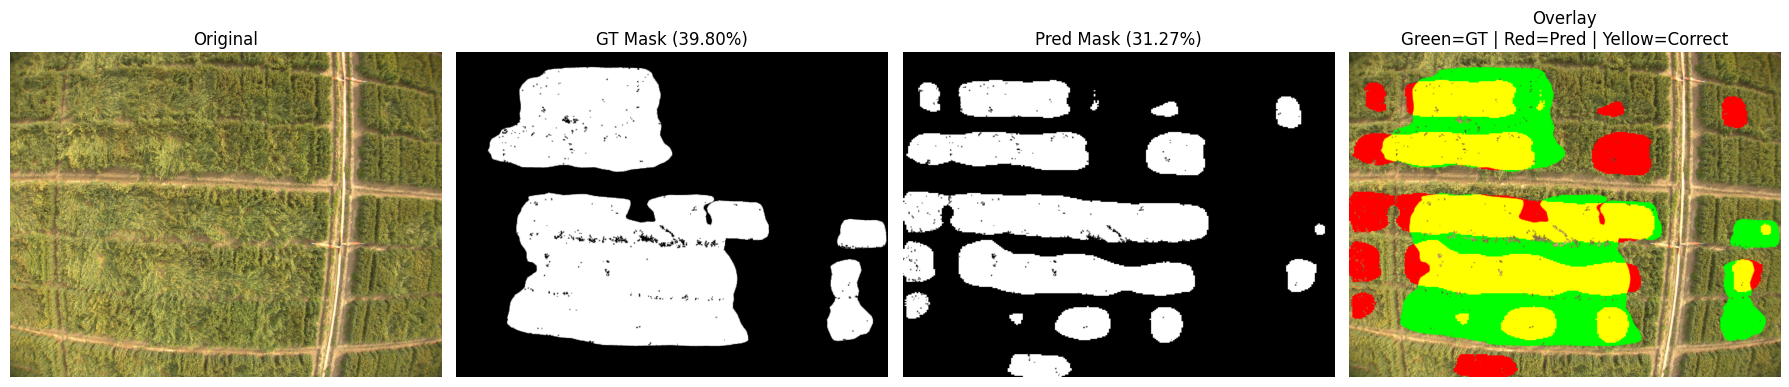

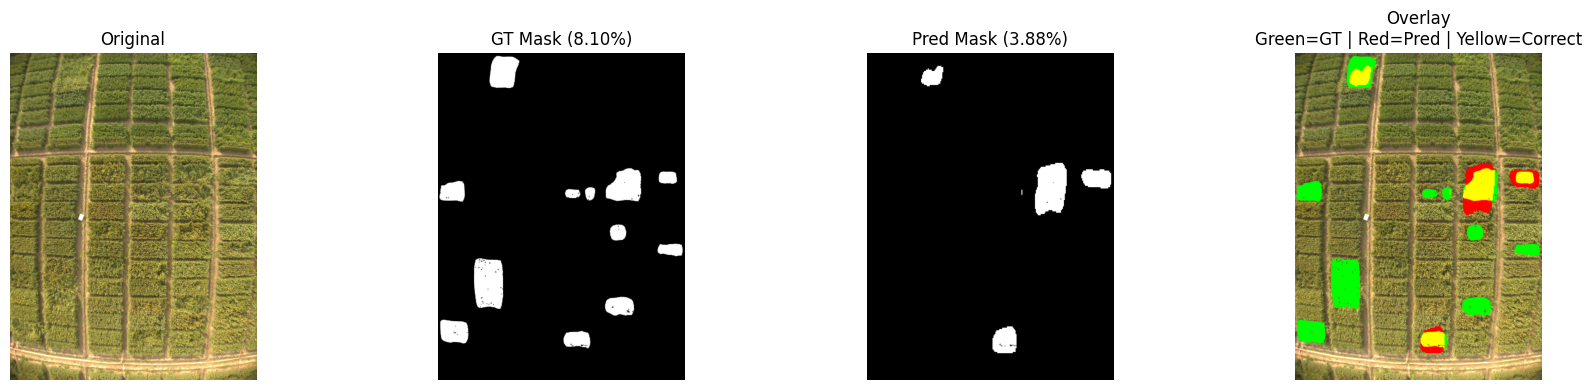

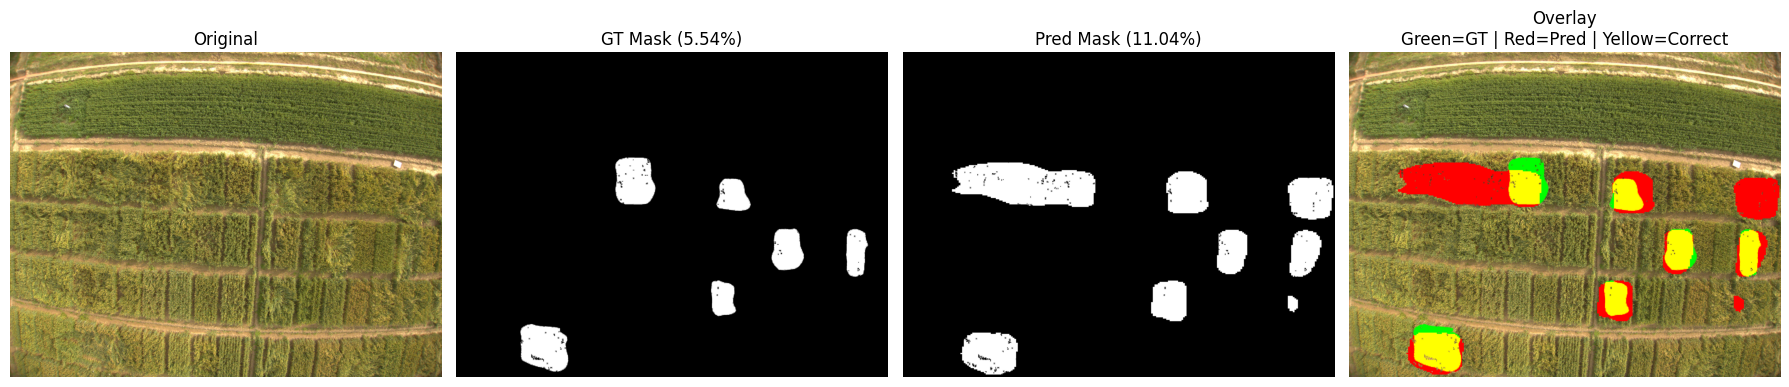

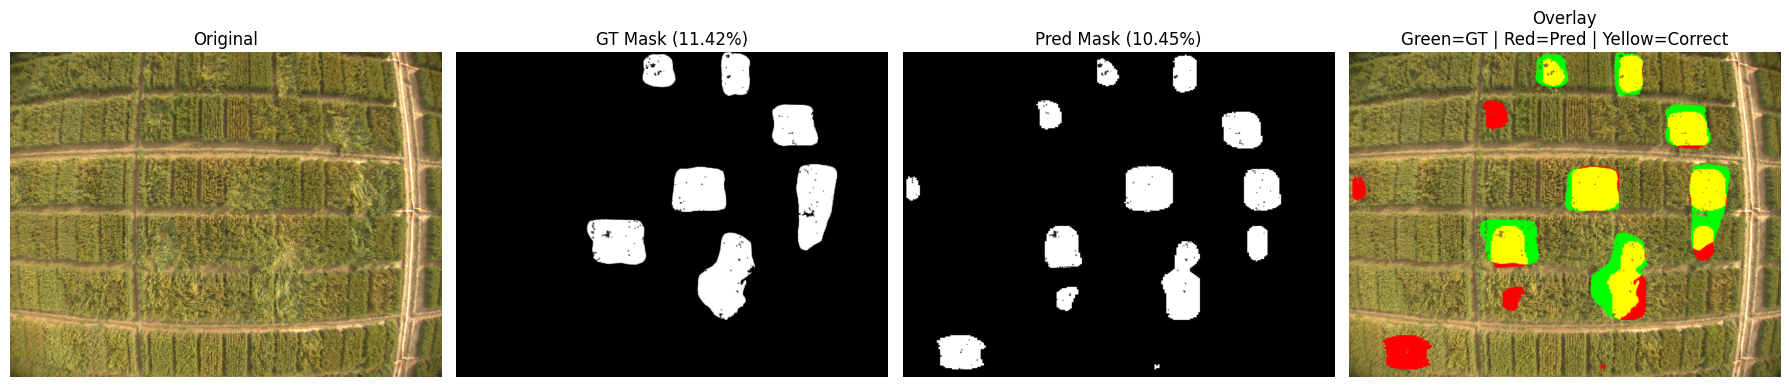

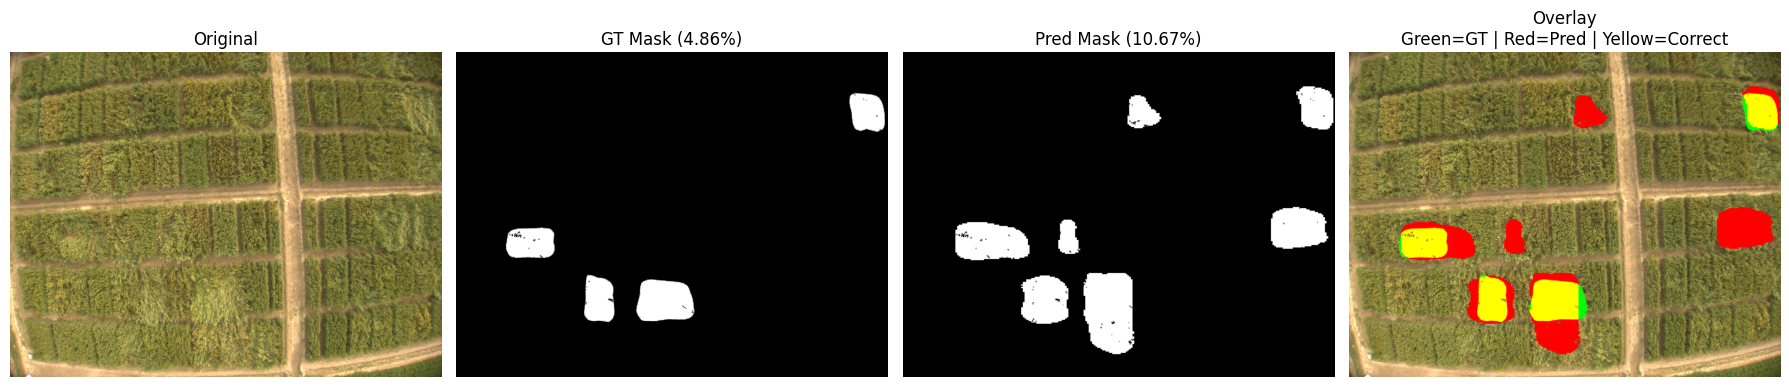

In [ ]:
samples = test_df.sample(5)

for idx, row in samples.iterrows():
    file = row["image"]


    orig = cv2.cvtColor(cv2.imread(os.path.join(orig_dir, file)), cv2.COLOR_BGR2RGB)
    crop = cv2.imread(os.path.join(crop_dir, file), 0)
    gt = cv2.imread(os.path.join(damage_dir, file), 0)

    h, w = orig.shape[:2]


    aug = val_tf(image=orig)
    inp = aug["image"].float().unsqueeze(0).to(device)

    with torch.no_grad():
        pred_mask = model(inp).squeeze().cpu().numpy()

    pred_bin = pred_mask > 0.5


    pred_bin = cv2.resize(
        pred_bin.astype(np.uint8),
        (w, h),
        interpolation=cv2.INTER_NEAREST
    ).astype(bool)


    crop_mask = crop == 255
    gt_mask = (gt == 255) & crop_mask
    pred_mask_final = pred_bin & crop_mask   # 🔥 ensure only crop area


    pred_percent = compute_damage_percent(pred_mask_final, crop)
    gt_percent = compute_damage_percent(gt_mask, crop)

    overlay = orig.copy()


    overlay[gt_mask] = [0, 255, 0]

    overlay[pred_mask_final] = [255, 0, 0]


    overlap = gt_mask & pred_mask_final
    overlay[overlap] = [255, 255, 0]


    plt.figure(figsize=(18,4))

    plt.subplot(1,4,1)
    plt.imshow(orig)
    plt.title("Original", fontsize=12)
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(gt_mask, cmap='gray')
    plt.title(f"GT Mask ({gt_percent:.2f}%)", fontsize=12)
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(pred_mask_final, cmap='gray')
    plt.title(f"Pred Mask ({pred_percent:.2f}%)", fontsize=12)
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(overlay)
    plt.title("Overlay\nGreen=GT | Red=Pred | Yellow=Correct", fontsize=12)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

**Load Model Anytime**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMG_3091_jpeg.rf.528e579afa2fa0c96606260ada7c1fb0.jpg to IMG_3091_jpeg.rf.528e579afa2fa0c96606260ada7c1fb0.jpg


In [ ]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def C(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = C(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = C(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = C(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = C(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = C(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = C(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = C(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))